# Frozen Encoder Geometry Refiner

Train the geometry transformer and optional SE3 refiner from a frozen FoldTree2 encoder. The notebook uses `learn_geometry_lightning.py` so the training path stays aligned with the script, then visualizes TensorBoard losses and one example structure with true, coarse, and SE3-refined CA/C/CB/N atoms.

In [ ]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import copy
import os
import shlex
import subprocess
import sys
from types import SimpleNamespace

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp")

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch_geometric.loader import DataLoader
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

start = Path.cwd().resolve()
candidates = [start, *start.parents]
REPO = None
for candidate in candidates:
    if (candidate / "learn_geometry_lightning.py").exists():
        REPO = candidate
        break
    package_dir = candidate / "foldtree2"
    if (package_dir / "learn_geometry_lightning.py").exists():
        REPO = package_dir
        break
if REPO is None:
    raise RuntimeError(f"Could not find learn_geometry_lightning.py from {start}")

os.chdir(REPO)
os.environ.setdefault("PYTHONPATH", str(REPO.parent))

print("repo:", REPO)
print("python:", sys.executable)
print("cuda:", torch.cuda.is_available())


## Configuration

The defaults below are sized for bounded validation runs, not final training. The key controls from the Lightning script are exposed here: deterministic validation split, individual loss switches, and the new coarse C/CB/N placement losses that drive atom-derived backbone angles.


In [ ]:
cfg = SimpleNamespace(
    dataset="notebooks/structs_training_mk2.h5",
    pretrained_encoder_path="/home/dmoi/projects/foldtree2/models/production/30char_minimal_decoder/final_30char_contacts_aa_encoder_full_epoch_52.pt",
    pretrained_encoder_full_path="/home/dmoi/projects/foldtree2/models/production/30char_minimal_decoder/final_30char_contacts_aa_encoder_full_epoch_52.pt",
    checkpoint_dir="/tmp/foldtree2_geometry_refiner_notebook",
    experiment_name="coarse_atoms_angle_from_geometry",
    epochs=5,
    limit_train_batches=2000,
    limit_val_batches=200,
    batch_size=2,
    val_batch_size=None,
    target_effective_batch_size=10,
    val_fraction=0.1,
    val_count=None,
    split_seed=42,
    learning_rate=5e-4,
    weight_decay=0.0,
    lr_scheduler="cosine",
    lr_scheduler_interval="epoch",
    lr_scheduler_frequency=1,
    lr_scheduler_monitor="val/loss",
    lr_warmup_epochs=0,
    lr_min=1e-6,
    lr_step_size=10,
    lr_gamma=0.5,
    accelerator="cuda",
    devices="2",
    precision="32-true",
    use_uncertainty_weighting=False,
    use_se3=False,
    use_se3_atom_refine=True,
    se3_hidden=16,
    se3_depth=2,
    se3_heads=4,
    se3_dim_head=8,
    transformer_width=256,
    transformer_layers=2,
    transformer_nheads=8,
    coarse_ca_weight=1.0,
    coarse_ca_step_weight=1.0,
    coarse_ca_bond_weight=0.1,
    coarse_ca_pairwise_weight=0.1,
    coarse_backbone_atom_weight=0.05,
    coarse_c_weight=0.05,
    coarse_cb_weight=0.05,
    coarse_n_weight=0.05,
    coarse_backbone_fape_weight=0.25,
    coarse_backbone_angle_weight=0.05,
    se3_atom_weight=0.05,
    se3_atom_fape_weight=0.25,
    log_every_n_steps=1,
    save_top_k=-1,
    preview_index=0,
)

Path(cfg.checkpoint_dir).mkdir(parents=True, exist_ok=True)
cfg


## Loss Profiles

These profiles mirror the script flags. Use `coarse_ca_only` first to verify the CA trace objective. Use `coarse_atoms_angle_from_geometry` to train C/CB/N placement and compute angle loss from placed atoms instead of the direct angle head.


In [ ]:
LOSS_PROFILES = {
    "coarse_ca_only": {
        "use_frame_fape_loss": False,
        "use_quat_geodesic_loss": False,
        "use_decoder_angle_loss": False,
        "use_coarse_ca_loss": True,
        "use_coarse_ca_step_loss": True,
        "use_coarse_ca_bond_loss": True,
        "use_coarse_ca_pairwise_loss": True,
        "use_coarse_backbone_loss": False,
    },
    "coarse_ca_step_only": {
        "use_frame_fape_loss": False,
        "use_quat_geodesic_loss": False,
        "use_decoder_angle_loss": False,
        "use_coarse_ca_loss": True,
        "use_coarse_ca_step_loss": True,
        "use_coarse_ca_bond_loss": False,
        "use_coarse_ca_pairwise_loss": False,
        "use_coarse_backbone_loss": False,
    },
    "coarse_ca_pairwise_only": {
        "use_frame_fape_loss": False,
        "use_quat_geodesic_loss": False,
        "use_decoder_angle_loss": False,
        "use_coarse_ca_loss": True,
        "use_coarse_ca_step_loss": False,
        "use_coarse_ca_bond_loss": False,
        "use_coarse_ca_pairwise_loss": True,
        "use_coarse_backbone_loss": False,
    },
    "coarse_atoms_angle_from_geometry": {
        "use_frame_fape_loss": False,
        "use_quat_geodesic_loss": False,
        "use_decoder_angle_loss": False,
        "use_coarse_ca_loss": True,
        "use_coarse_ca_step_loss": True,
        "use_coarse_ca_bond_loss": True,
        "use_coarse_ca_pairwise_loss": True,
        "use_coarse_backbone_loss": True,
        "use_coarse_backbone_atom_loss": False,
        "use_coarse_c_loss": True,
        "use_coarse_cb_loss": True,
        "use_coarse_n_loss": True,
        "use_coarse_backbone_fape_loss": False,
        "use_coarse_backbone_angle_loss": True,
    },
    "direct_angle_head_baseline": {
        "use_frame_fape_loss": False,
        "use_quat_geodesic_loss": False,
        "use_decoder_angle_loss": True,
        "use_coarse_ca_loss": False,
        "use_coarse_backbone_loss": False,
    },
}

LOSS_DEFAULTS = {
    "use_frame_fape_loss": True,
    "use_quat_geodesic_loss": True,
    "use_decoder_angle_loss": True,
    "use_coarse_ca_loss": False,
    "use_coarse_ca_step_loss": True,
    "use_coarse_ca_bond_loss": True,
    "use_coarse_ca_pairwise_loss": True,
    "use_coarse_backbone_loss": False,
    "use_coarse_backbone_atom_loss": True,
    "use_coarse_c_loss": False,
    "use_coarse_cb_loss": False,
    "use_coarse_n_loss": False,
    "use_coarse_backbone_fape_loss": True,
    "use_coarse_backbone_angle_loss": True,
    "use_se3_residue_loss": True,
    "use_se3_angle_loss": True,
    "use_se3_atom_loss": True,
    "use_se3_atom_fape_loss": True,
}


def active_loss_switches(profile_name=None):
    profile_name = profile_name or cfg.experiment_name
    switches = dict(LOSS_DEFAULTS)
    switches.update(LOSS_PROFILES[profile_name])
    return switches


def bool_flag(name, enabled):
    cli_name = name.replace("_", "-")
    return f"--{cli_name}" if enabled else f"--no-{cli_name}"

print("active profile:", cfg.experiment_name)
for key, value in active_loss_switches().items():
    print(f"  {key}: {value}")


## Train

This trains only the geometry transformer and optional SE3 decoder. The encoder is loaded from the checkpoint and frozen by `GeometryFocusedModule`. Every run uses the validation split configured above, and checkpoints monitor `val/loss`.


In [ ]:
def append_optional(cmd, option, value):
    if value is not None:
        cmd.extend([option, str(value)])


def build_train_command(profile_name=None):
    profile_name = profile_name or cfg.experiment_name
    switches = active_loss_switches(profile_name)
    run_dir = Path(cfg.checkpoint_dir) / profile_name
    run_dir.mkdir(parents=True, exist_ok=True)

    cmd = [
        sys.executable,
        "learn_geometry_lightning.py",
        "--dataset", cfg.dataset,
        "--epochs", str(cfg.epochs),
        "--batch-size", str(cfg.batch_size),
        "--target-effective-batch-size", str(cfg.target_effective_batch_size),
        "--accelerator", cfg.accelerator,
        "--devices", cfg.devices,
        "--precision", cfg.precision,
        "--pretrained-encoder-path", cfg.pretrained_encoder_path,
        "--pretrained-encoder-full-path", cfg.pretrained_encoder_full_path,
        "--val-fraction", str(cfg.val_fraction),
        "--split-seed", str(cfg.split_seed),
        "--learning-rate", str(cfg.learning_rate),
        "--weight-decay", str(cfg.weight_decay),
        "--lr-scheduler", str(cfg.lr_scheduler),
        "--lr-scheduler-interval", str(cfg.lr_scheduler_interval),
        "--lr-scheduler-frequency", str(cfg.lr_scheduler_frequency),
        "--lr-scheduler-monitor", str(cfg.lr_scheduler_monitor),
        "--lr-warmup-epochs", str(cfg.lr_warmup_epochs),
        "--lr-min", str(cfg.lr_min),
        "--lr-step-size", str(cfg.lr_step_size),
        "--lr-gamma", str(cfg.lr_gamma),
        "--coarse-ca-weight", str(cfg.coarse_ca_weight),
        "--coarse-ca-step-weight", str(cfg.coarse_ca_step_weight),
        "--coarse-ca-bond-weight", str(cfg.coarse_ca_bond_weight),
        "--coarse-ca-pairwise-weight", str(cfg.coarse_ca_pairwise_weight),
        "--coarse-ca-step-frame", "prev",
        "--rotation-target-frame", "local",
        "--coarse-backbone-atom-weight", str(cfg.coarse_backbone_atom_weight),
        "--coarse-c-weight", str(cfg.coarse_c_weight),
        "--coarse-cb-weight", str(cfg.coarse_cb_weight),
        "--coarse-n-weight", str(cfg.coarse_n_weight),
        "--coarse-backbone-fape-weight", str(cfg.coarse_backbone_fape_weight),
        "--coarse-backbone-angle-weight", str(cfg.coarse_backbone_angle_weight),
        "--transformer-width", str(cfg.transformer_width),
        "--transformer-layers", str(cfg.transformer_layers),
        "--transformer-nheads", str(cfg.transformer_nheads),
        "--rt-hidden", "64,32,16",
        "--rotation-hidden", "64,32,16",
        "--ca-step-hidden", "64,32,16",
        "--angles-hidden", "64,32,16",
        "--ss-hidden", "32,16,8",
        "--checkpoint-dir", str(run_dir),
        "--save-top-k", str(cfg.save_top_k),
        "--log-every-n-steps", str(cfg.log_every_n_steps),
    ]
    append_optional(cmd, "--limit-train-batches", cfg.limit_train_batches)
    append_optional(cmd, "--limit-val-batches", cfg.limit_val_batches)
    append_optional(cmd, "--val-batch-size", cfg.val_batch_size)
    append_optional(cmd, "--val-count", cfg.val_count)

    cmd.append("--use-uncertainty-weighting" if cfg.use_uncertainty_weighting else "--no-use-uncertainty-weighting")
    for name, enabled in switches.items():
        cmd.append(bool_flag(name, enabled))

    if cfg.use_se3:
        cmd += [
            "--use-se3",
            "--se3-input-source", "coarse_ca",
            "--se3-hidden", str(cfg.se3_hidden),
            "--se3-depth", str(cfg.se3_depth),
            "--se3-heads", str(cfg.se3_heads),
            "--se3-dim-head", str(cfg.se3_dim_head),
        ]
        if cfg.use_se3_atom_refine:
            cmd += [
                "--use-se3-atom-refine",
                "--se3-atom-weight", str(cfg.se3_atom_weight),
                "--se3-atom-fape-weight", str(cfg.se3_atom_fape_weight),
            ]
    else:
        cmd += ["--no-use-se3"]

    return cmd

cmd = build_train_command(cfg.experiment_name)
print(shlex.join(cmd))
subprocess.run(cmd, check=True, cwd=REPO, env=os.environ.copy())


## Loss Curves

The plot includes both training and validation tags for the coarse CA objective, separate C/CB/N placement losses, and atom-derived backbone angle loss. Missing panels usually mean that loss switch was disabled for the active profile.


In [ ]:
def latest_lightning_log(root="lightning_logs"):
    root = Path(root)
    versions = sorted(root.glob("version_*"), key=lambda p: p.stat().st_mtime)
    if not versions:
        raise FileNotFoundError(f"No Lightning logs found in {root}")
    return versions[-1]


def load_scalars(logdir):
    ea = EventAccumulator(str(logdir))
    ea.Reload()
    out = {}
    for tag in ea.Tags().get("scalars", []):
        events = ea.Scalars(tag)
        out[tag] = {
            "step": np.array([x.step for x in events], dtype=np.int64),
            "value": np.array([x.value for x in events], dtype=np.float32),
        }
    return out

logdir = latest_lightning_log()
scalars = load_scalars(logdir)
print("logdir:", logdir)
print("scalar tags:")
for tag in sorted(k for k in scalars if "raw" in k or k.endswith("/loss") or "loss_epoch" in k):
    print(" ", tag)

plot_tags = [
    "train/loss_epoch",
    "val/loss",
    "train/raw_coarse_ca",
    "val/raw_coarse_ca",
    "train/raw_coarse_c",
    "val/raw_coarse_c",
    "train/raw_coarse_cb",
    "val/raw_coarse_cb",
    "train/raw_coarse_n",
    "val/raw_coarse_n",
    "train/raw_coarse_backbone_angles",
    "val/raw_coarse_backbone_angles",
    "train/raw_angles",
    "val/raw_angles",
]

fig, axes = plt.subplots(4, 4, figsize=(18, 12))
axes = axes.ravel()
for ax, tag in zip(axes, plot_tags):
    series = scalars.get(tag)
    if series is None or len(series["value"]) == 0:
        ax.set_title(tag + "\nmissing")
        ax.axis("off")
        continue
    ax.plot(series["step"], series["value"], marker="o", linewidth=1.5)
    ax.set_title(tag)
    ax.set_xlabel("step")
    ax.grid(alpha=0.25)
for ax in axes[len(plot_tags):]:
    ax.axis("off")
plt.tight_layout()


## Reload Checkpoints And Predict One Example Per Epoch

This cell reconstructs the frozen encoder and decoder modules, loads each epoch checkpoint, runs one fixed structure from the HDF5 dataset through `_compute_total_loss`, and stores prediction tensors for visualization.

In [ ]:
import re

from learn_geometry_lightning import (
    GeometryFocusedModule,
    build_decoders,
    build_encoder,
    ensure_edge_attrs_inplace,
    ensure_float32_inplace,
)
from foldtree2.src import pdbgraphmk2


def notebook_args():
    return SimpleNamespace(
        pretrained_encoder_path=cfg.pretrained_encoder_path,
        pretrained_encoder_full_path=cfg.pretrained_encoder_full_path,
        fallback_latent_dim=64,
        transformer_width=cfg.transformer_width,
        transformer_layers=cfg.transformer_layers,
        transformer_nheads=cfg.transformer_nheads,
        transformer_dropout=0.05,
        rt_hidden="64,32,16",
        rotation_hidden="64,32,16",
        ca_step_hidden="64,32,16",
        ss_hidden="32,16,8",
        angles_hidden="64,32,16",
        use_se3=cfg.use_se3,
        se3_hidden=cfg.se3_hidden,
        se3_out_channels=96,
        se3_depth=cfg.se3_depth,
        se3_heads=cfg.se3_heads,
        se3_dim_head=cfg.se3_dim_head,
    )


def checkpoint_epoch(path: Path):
    matches = re.findall(r"epoch(?:=|-)(\d+)", path.stem)
    if matches:
        return int(matches[-1])
    return None


def epoch_order_key(path: Path):
    epoch = checkpoint_epoch(path)
    if epoch is None:
        return (10**9, path.stat().st_mtime)
    return (epoch, path.stat().st_mtime)


dataset = pdbgraphmk2.StructureDataset(cfg.dataset)
if len(dataset) == 0:
    raise RuntimeError(f"Dataset has no entries: {cfg.dataset}")

sample_idx = int(getattr(cfg, "preview_index", 0))
sample_idx = max(0, min(sample_idx, len(dataset) - 1))
print(f"preview sample index: {sample_idx} / {len(dataset) - 1}")

sample_loader = DataLoader([dataset[sample_idx]], batch_size=1, shuffle=False)
sample_batch = next(iter(sample_loader))

device = torch.device("cuda" if torch.cuda.is_available() and cfg.accelerator != "cpu" else "cpu")
sample_batch = ensure_edge_attrs_inplace(ensure_float32_inplace(sample_batch.to(device)), edge_dim=1)

args = notebook_args()
encoder, latent_dim = build_encoder(args, copy.deepcopy(sample_batch), device)
se3_num_atom_types = max(4, int(getattr(encoder, "num_embeddings", 20)))
transformer_decoder, se3_decoder = build_decoders(
    latent_dim,
    copy.deepcopy(sample_batch),
    device,
    cfg.use_se3,
    args,
    se3_num_atom_types,
)

active_checkpoint_dir = Path(cfg.checkpoint_dir) / cfg.experiment_name
all_ckpts = sorted(active_checkpoint_dir.glob("*.ckpt"), key=epoch_order_key)
if not all_ckpts:
    raise FileNotFoundError(f"No checkpoints found in {active_checkpoint_dir}")

# Keep one checkpoint per epoch (latest mtime for ties).
epoch_to_ckpt = {}
for ckpt in all_ckpts:
    epoch = checkpoint_epoch(ckpt)
    if epoch is None:
        continue
    epoch_to_ckpt[epoch] = ckpt

if not epoch_to_ckpt:
    raise RuntimeError("No epoch checkpoints found. Ensure training uses --save-top-k -1.")

epoch_previews = []
for epoch in sorted(epoch_to_ckpt):
    ckpt = epoch_to_ckpt[epoch]
    module = GeometryFocusedModule.load_from_checkpoint(
        str(ckpt),
        encoder=encoder,
        transformer_geom_decoder=transformer_decoder,
        se3_decoder=se3_decoder,
        map_location=device,
        learning_rate=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
        lr_scheduler_name=cfg.lr_scheduler,
        lr_scheduler_interval=cfg.lr_scheduler_interval,
        lr_scheduler_frequency=cfg.lr_scheduler_frequency,
        lr_scheduler_monitor=cfg.lr_scheduler_monitor,
        lr_warmup_epochs=cfg.lr_warmup_epochs,
        lr_min=cfg.lr_min,
        lr_step_size=cfg.lr_step_size,
        lr_gamma=cfg.lr_gamma,
        max_epochs=cfg.epochs,
        clip_grad_norm=1.0,
        cache_flush_interval=0,
        gc_collect_interval=0,
        use_cuda_ipc_collect=False,
        use_uncertainty_weighting=cfg.use_uncertainty_weighting,
        use_se3=cfg.use_se3,
        **active_loss_switches(cfg.experiment_name),
        coarse_ca_weight=cfg.coarse_ca_weight,
        coarse_ca_step_weight=cfg.coarse_ca_step_weight,
        coarse_ca_bond_weight=cfg.coarse_ca_bond_weight,
        coarse_ca_pairwise_weight=cfg.coarse_ca_pairwise_weight,
        rotation_target_frame="local",
        coarse_backbone_atom_weight=cfg.coarse_backbone_atom_weight,
        coarse_c_weight=cfg.coarse_c_weight,
        coarse_cb_weight=cfg.coarse_cb_weight,
        coarse_n_weight=cfg.coarse_n_weight,
        coarse_backbone_fape_weight=cfg.coarse_backbone_fape_weight,
        coarse_backbone_angle_weight=cfg.coarse_backbone_angle_weight,
        use_se3_atom_refine=cfg.use_se3_atom_refine,
        se3_atom_weight=cfg.se3_atom_weight,
        se3_atom_fape_weight=cfg.se3_atom_fape_weight,
    )
    module.eval().to(device)

    with torch.no_grad():
        pred_batch = copy.deepcopy(sample_batch)
        total, raw_terms, weighted_terms, se3_skip, _ = module._compute_total_loss(
            pred_batch,
            debug_label=f"epoch_{epoch}",
        )

    epoch_previews.append(
        {
            "epoch": epoch,
            "ckpt": ckpt,
            "total": float(total.detach().cpu()),
            "raw_terms": {k: float(v.detach().cpu()) for k, v in raw_terms.items()},
            "weighted_terms": {k: float(v.detach().cpu()) for k, v in weighted_terms.items()},
            "se3_skip": bool(se3_skip),
            "pred_batch": pred_batch,
        }
    )

print(f"loaded {len(epoch_previews)} epoch checkpoints")
for preview in epoch_previews:
    print(
        f"epoch={preview['epoch']:03d} total={preview['total']:.5f} "
        f"se3_skip={preview['se3_skip']} ckpt={preview['ckpt'].name}"
    )

# Keep compatibility with downstream cells that expect pred_batch.
pred_batch = epoch_previews[-1]["pred_batch"]
print("identifier:", getattr(pred_batch, "identifier", None))

## Structure Visualizations

Plots are centered independently for visual comparison. Use them to catch gross frame flips, trace collapse, exploding SE3 coordinates, or CB/N/C offsets pointing the wrong way.

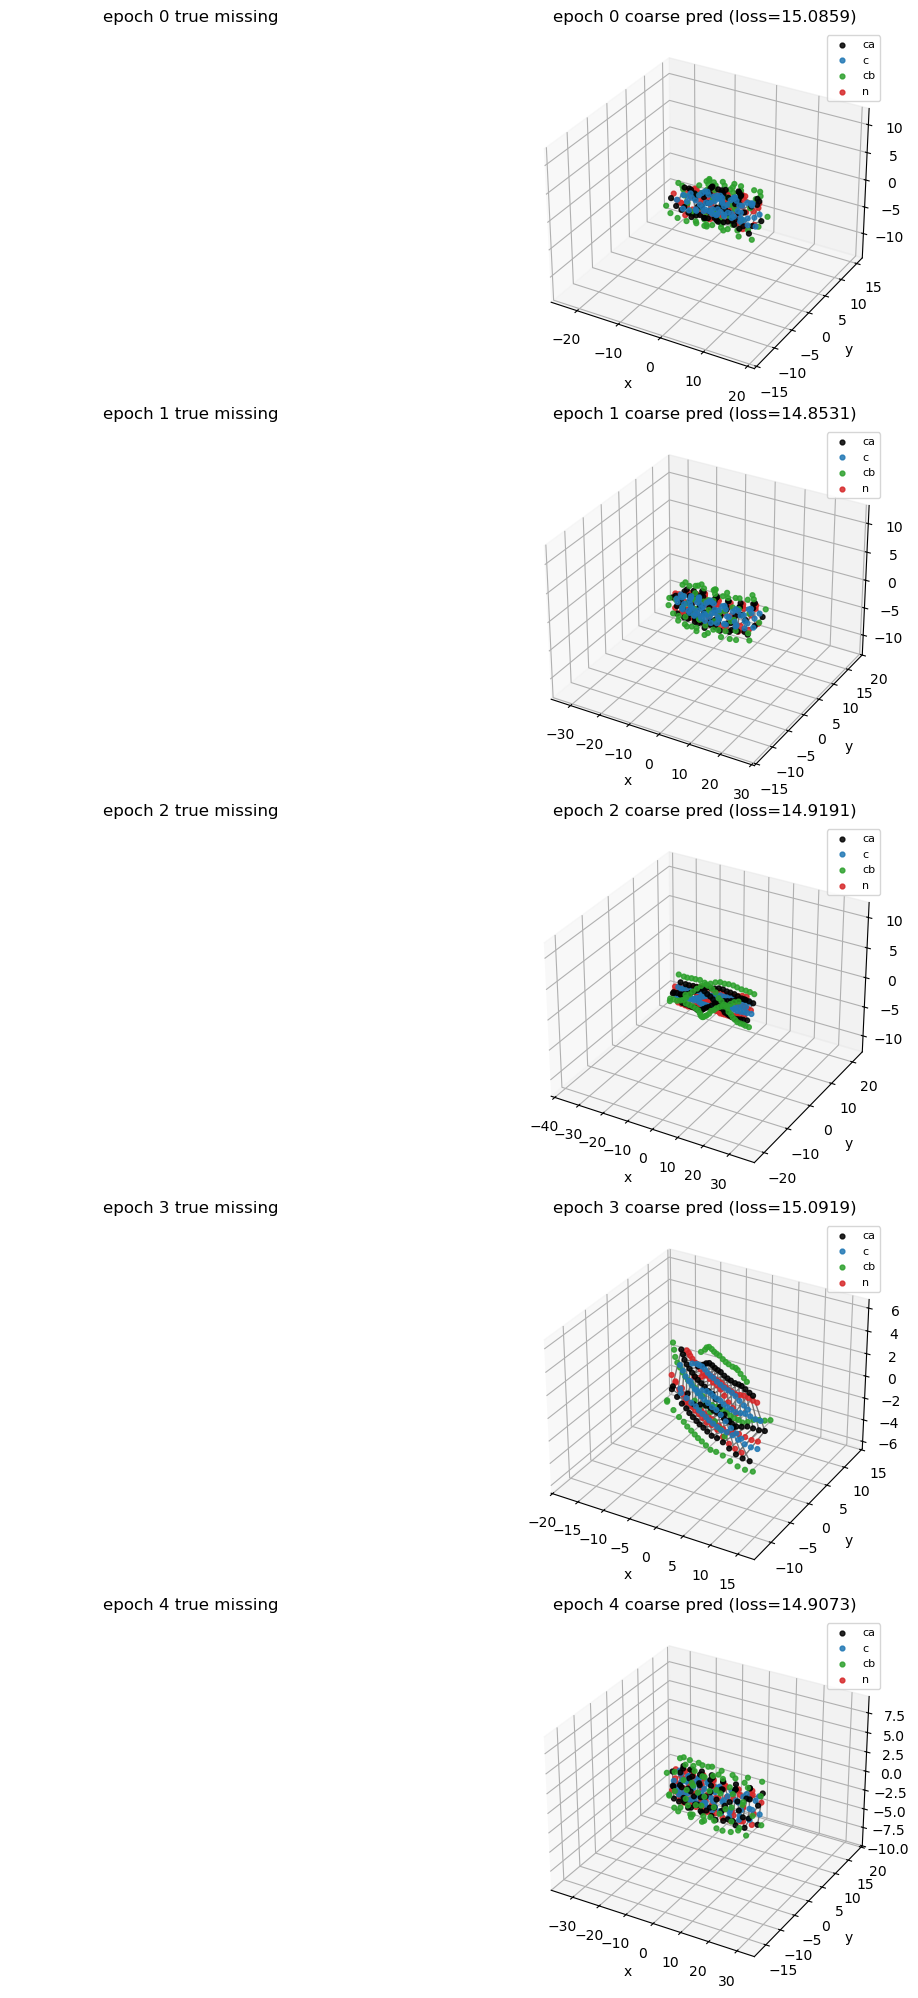

In [6]:
ATOM_COLORS = {"ca": "black", "c": "tab:blue", "cb": "tab:green", "n": "tab:red"}


def node_from_batch(batch, name):
    if name in batch.node_types and hasattr(batch[name], "x"):
        return batch[name].x.detach().cpu()
    return None


def stack_atoms(batch, prefix):
    atoms = []
    names = ["ca", "c", "cb", "n"]
    for name in names:
        key = "coords" if prefix == "true" and name == "ca" else f"{prefix}_{name}_pred"
        if prefix == "true" and name == "c":
            key = "ccoords"
        elif prefix == "true" and name == "cb":
            key = "cbcoords"
        elif prefix == "true" and name == "n":
            key = "ncoords"
        x = node_from_batch(batch, key)
        if x is None:
            return None, names
        atoms.append(x)
    return torch.stack(atoms, dim=1), names


def center(x):
    return x - x.reshape(-1, 3).mean(dim=0)


def plot_atoms(ax, atoms, names, title, stride=1):
    atoms = center(atoms)[::stride]
    ca = atoms[:, names.index("ca")]
    ax.plot(ca[:, 0], ca[:, 1], ca[:, 2], color="0.35", linewidth=1.0, alpha=0.8)
    for i, name in enumerate(names):
        pts = atoms[:, i]
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=12, color=ATOM_COLORS[name], label=name, alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend(loc="upper right", fontsize=8)


if "epoch_previews" not in globals() or not epoch_previews:
    raise RuntimeError("Run the checkpoint reload/predict cell first.")

# Per-epoch side-by-side: ground truth vs prediction for one fixed structure.
rows = len(epoch_previews)
fig = plt.figure(figsize=(12, 4 * rows))
for row_idx, preview in enumerate(epoch_previews):
    batch = preview["pred_batch"]
    true_atoms, atom_names = stack_atoms(batch, "true")
    pred_prefix = "se3" if ("se3_ca_pred" in batch.node_types) else "coarse"
    pred_atoms, _ = stack_atoms(batch, pred_prefix)

    ax_true = fig.add_subplot(rows, 2, 2 * row_idx + 1, projection="3d")
    ax_pred = fig.add_subplot(rows, 2, 2 * row_idx + 2, projection="3d")

    if true_atoms is None:
        ax_true.set_title(f"epoch {preview['epoch']} true missing")
        ax_true.axis("off")
    else:
        plot_atoms(ax_true, true_atoms, atom_names, f"epoch {preview['epoch']} ground truth")

    if pred_atoms is None:
        ax_pred.set_title(f"epoch {preview['epoch']} {pred_prefix} missing")
        ax_pred.axis("off")
    else:
        plot_atoms(
            ax_pred,
            pred_atoms,
            atom_names,
            f"epoch {preview['epoch']} {pred_prefix} pred (loss={preview['total']:.4f})",
        )

plt.tight_layout()

# Keep legacy panels for the distance-matrix cell using the final epoch.
final_preview = epoch_previews[-1]
final_batch = final_preview["pred_batch"]
true_atoms, atom_names = stack_atoms(final_batch, "true")
coarse_atoms, _ = stack_atoms(final_batch, "coarse")
se3_atoms, _ = stack_atoms(final_batch, "se3")
panels = [(true_atoms, "true"), (coarse_atoms, "coarse initial"), (se3_atoms, "SE3 refined")]

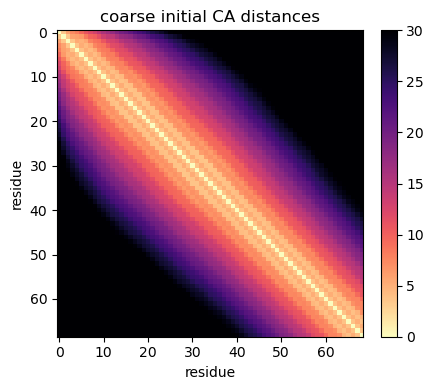

In [7]:
def ca_distance_matrix(atoms):
    ca = atoms[:, atom_names.index("ca")]
    return torch.cdist(ca, ca).numpy()

mats = []
titles = []
for atoms, title in panels:
    if atoms is not None:
        mats.append(ca_distance_matrix(atoms))
        titles.append(title)

fig, axes = plt.subplots(1, len(mats), figsize=(5 * len(mats), 4))
if len(mats) == 1:
    axes = [axes]
for ax, mat, title in zip(axes, mats, titles):
    im = ax.imshow(mat, cmap="magma_r", vmin=0, vmax=min(30, np.nanmax(mat)))
    ax.set_title(title + " CA distances")
    ax.set_xlabel("residue")
    ax.set_ylabel("residue")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()